In [5]:
from environments.environment import OthelloEnv

In [6]:
import random

env = OthelloEnv(board_size=5)
obs = env.reset()

done = False

while not done:
    action = random.choice(obs["legal_actions"])
    obs, reward, done, info = env.step(action)

env.render()

print("Final reward:", reward)
print("Winner:", info["winner"])
print("Disc difference:", info["disc_diff"])


Current player: O
Turn: 21

   0 1 2 3 4
0  X X X X X 
1  X X O X X 
2  X O O O O 
3  X X X O O 
4  O O O O O 

Final reward: 1
Winner: 1
Disc difference: 1


In [7]:
env = OthelloEnv(board_size=5)

obs = env.reset()
env.render()

print(obs["legal_actions"])



Current player: X
Turn: 0

   0 1 2 3 4
0  . . . . . 
1  . X O . . 
2  . O X . . 
3  . . . . . 
4  . . . . . 

[2, 8, 10, 16]


In [8]:
%run play_gui.py

In [9]:
from environments.environment import OthelloEnv
from agents.random_agent import RandomAgent
from agents.greedy_agent import GreedyAgent

env = OthelloEnv(board_size=5)

agent_x = RandomAgent(board_size=5)
agent_o = GreedyAgent(board_size=5)

obs = env.reset()
done = False

while not done:
    if env.current_player == 1:
        action = agent_x.select_action(obs)
    else:
        action = agent_o.select_action(obs)

    obs, reward, done, info = env.step(action)

env.render()
print(info)


Current player: O
Turn: 21

   0 1 2 3 4
0  X X X O O 
1  X X X X O 
2  X X X X X 
3  X O O X X 
4  O O O O O 

{'illegal_move': False, 'winner': 1, 'disc_diff': 5}


In [23]:
from environments.environment import OthelloEnv
from agents.random_agent import RandomAgent
from agents.greedy_agent import GreedyAgent
from agents.heuristic_agent import HeuristicAgent   
from environments import evaluation

evaluation.evaluate_fair(RandomAgent, GreedyAgent, board_size=5, n_games=100)




{'agent_a_wins': 36, 'agent_b_wins': 64, 'draws': 0, 'n_games': 100}

In [32]:
import dqn.train_dqn

print(dqn.train_dqn.__file__)

agent, rewards_history, wins_history = train_dqn(
    board_size=5,
    num_episodes=4000,
    model_path="models/othello_dqn.pth",
    opponent_type="heuristic",
)




c:\Users\barca\OneDrive - České vysoké učení technické v Praze\Plocha\cvut\2ms\AI_aerospace\othella\dqn\train_dqn.py
Training DQN against: heuristic
Episode 100/4000 | opponent=heuristic | epsilon=0.606 | avg_reward_100=-0.640 | winrate_100=0.180 | W/D/L=18/0/82
Episode 200/4000 | opponent=heuristic | epsilon=0.367 | avg_reward_100=-0.830 | winrate_100=0.085 | W/D/L=26/1/173
Episode 300/4000 | opponent=heuristic | epsilon=0.222 | avg_reward_100=-0.520 | winrate_100=0.240 | W/D/L=50/1/249
Episode 400/4000 | opponent=heuristic | epsilon=0.135 | avg_reward_100=0.100 | winrate_100=0.550 | W/D/L=105/1/294
Episode 500/4000 | opponent=heuristic | epsilon=0.082 | avg_reward_100=0.260 | winrate_100=0.630 | W/D/L=168/1/331
Episode 600/4000 | opponent=heuristic | epsilon=0.050 | avg_reward_100=0.310 | winrate_100=0.655 | W/D/L=233/2/365
Episode 700/4000 | opponent=heuristic | epsilon=0.050 | avg_reward_100=0.540 | winrate_100=0.770 | W/D/L=310/2/388
Episode 800/4000 | opponent=heuristic | epsilon

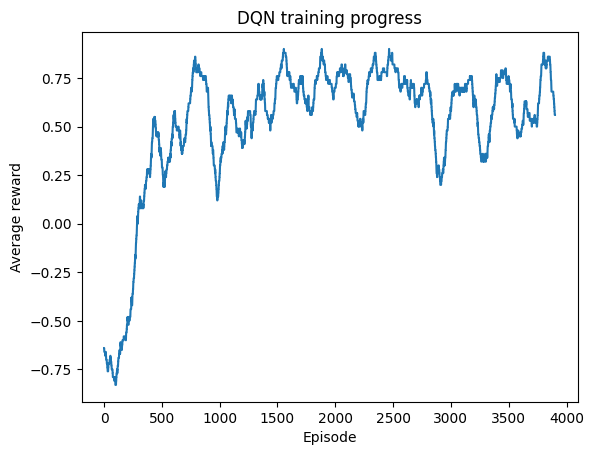

In [33]:
import matplotlib.pyplot as plt
import numpy as np

window = 100
moving_avg = np.convolve(
    rewards_history,
    np.ones(window) / window,
    mode="valid"
)

plt.plot(moving_avg)
plt.xlabel("Episode")
plt.ylabel("Average reward")
plt.title("DQN training progress")
plt.show()